# Week 4 Internship Task — Unsupervised Learning & Customer Segmentation

# Part 1 — Data Preprocessing & K-Means Clustering

# Step 1: Imports

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage

RANDOM_STATE = 42
CLUSTER_COLORS = ["#2b6cb0", "#c05621", "#276749", "#805ad5", "#b83280", "#d69e2e"]

# Step 2: Load the dataset and inspect it

Load the raw CSV and check its shape, column names, and data types before
touching anything, this tells how many rows/columns are working with
and flags any columns that aren't numeric

In [4]:
from google.colab import files
uploaded = files.upload()

Saving CC GENERAL.csv to CC GENERAL.csv


In [5]:
df = pd.read_csv("CC GENERAL.csv")

In [6]:
print("Shape:", df.shape)
print("\\nColumn dtypes:")
print(df.dtypes)
df.head()

Shape: (8950, 18)
\nColumn dtypes:
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


CUST_ID is a unique string identifier per customer (e.g. `C10001`) it
carries no behavioural information and would only confuse a distance-based
algorithm like K-Means, so it is dropped before any modeling.

In [7]:
df = df.drop(columns=["CUST_ID"])
print("Shape after dropping CUST_ID:", df.shape)


Shape after dropping CUST_ID: (8950, 17)


# Step 3: Identify and handle missing values

First count nulls per column. Clustering algorithms cannot
handle `NaN` values at all (they will error out), so every missing value must
be resolved before scaling. For this dataset the missing values sit in two
skewed financial columns (`MINIMUM_PAYMENTS`, `CREDIT_LIMIT`), so we fill
them with the **median** rather than the mean the median is robust to the
extreme outliers that are common in balance/payment data (a few customers
with very high limits would otherwise pull the mean upward and bias the
fill value). Dropping these rows was considered but rejected: `MINIMUM_PAYMENTS`
alone is missing for several hundred customers, and dropping that many rows
would throw away real behavioural signal for no good reason.

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()} out of {df.shape[0] * df.shape[1]}")

Columns with missing values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Total missing cells: 314 out of 152150


In [9]:
fig_missing = px.bar(
    x=missing.index, y=missing.values,
    labels={"x": "Feature", "y": "Missing count"},
    title="Missing Values by Feature (pre-imputation)",
    color=missing.values, color_continuous_scale="Sunsetdark",
)
fig_missing.update_layout(showlegend=False, coloraxis_showscale=False)
fig_missing.show()

In [10]:
for col in missing.index:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"Filled {col} missing values with median = {median_value:.2f}")

print("\\nRemaining missing values:", df.isnull().sum().sum())

Filled CREDIT_LIMIT missing values with median = 3000.00
Filled MINIMUM_PAYMENTS missing values with median = 312.34
\nRemaining missing values: 0


# Step 4: Scale all features

**Why is scaling mandatory for clustering?** K-Means (and hierarchical
clustering) group points based on **Euclidean distance**. If features are
left on their original scales, a column like `CASH_ADVANCE` (values up to
tens of thousands) would completely dominate the distance calculation over
a column like `BALANCE_FREQUENCY` (values between 0 and 1) not because it's
more important, but purely because of its numeric range. `StandardScaler`
transforms every feature to mean 0, standard deviation 1, so each feature
contributes proportionally to distance based on its actual variation in the
data, not its arbitrary unit of measurement

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaled data shape:", X_scaled_df.shape)
X_scaled_df.describe().round(2).loc[["mean", "std"]]

Scaled data shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
mean,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# Step 5: K-Means for k = 2 to 10 — record inertia

**Inertia** is the within-cluster sum of squares: the total squared distance
of every point to its assigned cluster centroid. Lower inertia means tighter
clusters, but inertia always decreases as k increases (more clusters can
always fit the data more closely), so look at *how much* it drops at each
step rather than its absolute value

In [12]:
inertias = []
k_range = list(range(2, 11))

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k:2d}  ->  inertia = {kmeans.inertia_:,.1f}")

k= 2  ->  inertia = 127,784.5
k= 3  ->  inertia = 111,975.0
k= 4  ->  inertia = 99,061.9
k= 5  ->  inertia = 91,490.5
k= 6  ->  inertia = 84,826.6
k= 7  ->  inertia = 79,856.2
k= 8  ->  inertia = 74,484.9
k= 9  ->  inertia = 69,828.7
k=10  ->  inertia = 66,466.4


# Step 6: Elbow Curve

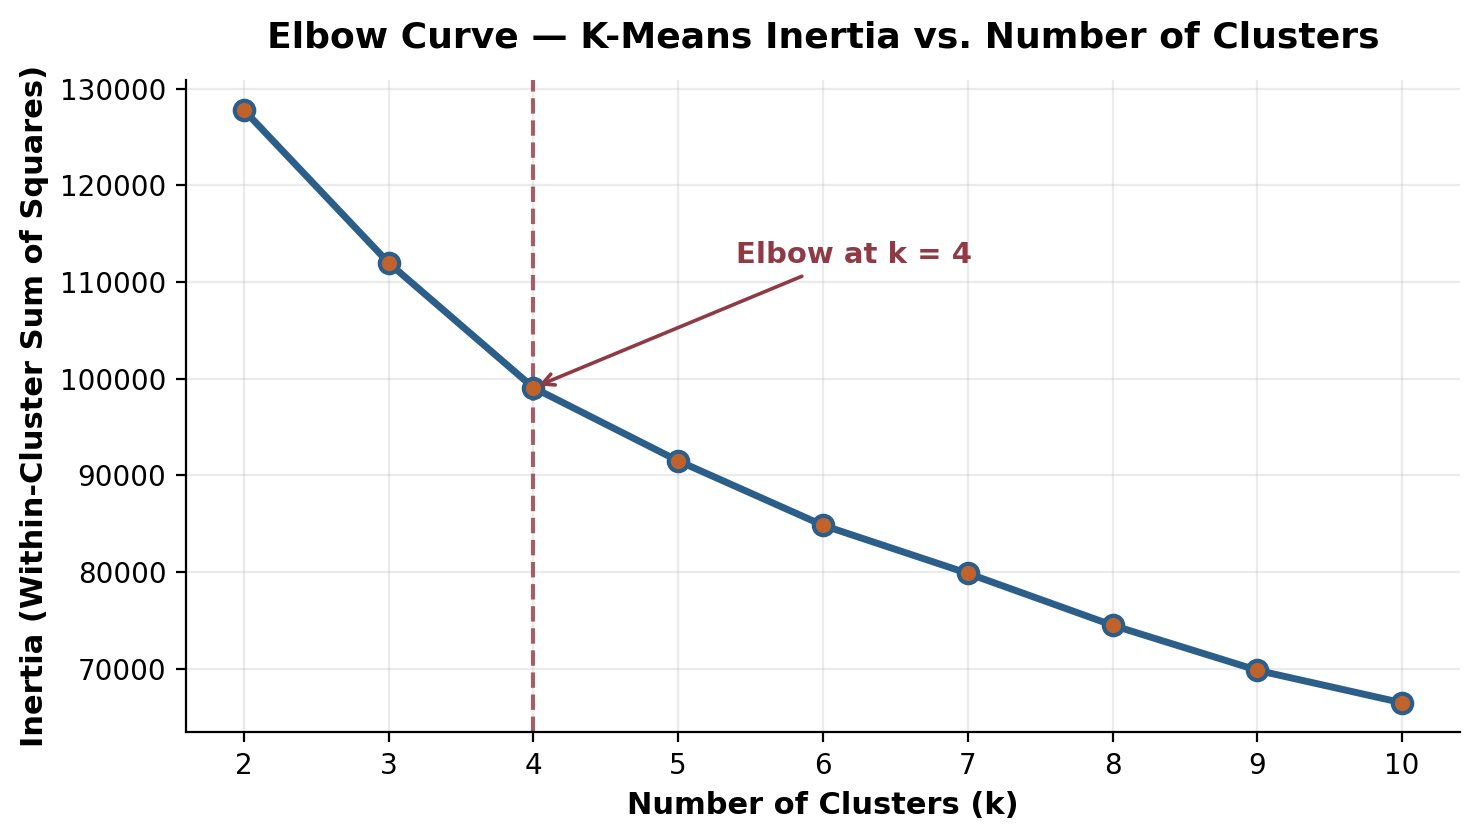

In [13]:
import matplotlib.pyplot as plt

k_range = list(range(2, 11))
inertias = [127784.5, 111975.0, 99061.9, 91490.5, 84826.6,
            79856.2, 74484.9, 69828.7, 66466.4]

fig, ax = plt.subplots(figsize=(7.5, 4.3), dpi=200)

ax.plot(
    k_range, inertias, marker="o", linewidth=2.5, color="#2b5f8a",
    markersize=7, markerfacecolor="#c0622b", markeredgecolor="#2b5f8a",
    markeredgewidth=1.5, zorder=3,
)

# Vertical dashed line marking the chosen k
ax.axvline(x=4, color="#8e3b46", linestyle="--", linewidth=1.5, alpha=0.8, zorder=2)

# Annotation with arrow pointing at the elbow
ax.annotate(
    "Elbow at k = 4", xy=(4, 99061.9), xytext=(5.4, 112000),
    fontsize=10.5, color="#8e3b46", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#8e3b46", lw=1.3),
)

ax.set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="bold")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=11, fontweight="bold")
ax.set_title("Elbow Curve — K-Means Inertia vs. Number of Clusters", fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(k_range)
ax.grid(alpha=0.25, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Reading the elbow curve:** Inertia drops sharply from k=2 to k=4, then
the rate of decrease flattens noticeably the "elbow" sits around **k=4 to
k=5**, after which adding more clusters buys progressively less improvement
for the added complexity

# Step 7: Silhouette Score for each k

The **silhouette score** measures how well-separated clusters are: For each
point it compares its average distance to points in its own cluster against
its average distance to points in the nearest other cluster. Scores range
from -1 to 1 higher means clusters are dense and well separated, values
near 0 mean clusters overlap.

In [14]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k:2d}  ->  silhouette score = {score:.4f}")

fig_sil = go.Figure()
fig_sil.add_trace(go.Bar(
    x=k_range, y=silhouette_scores,
    marker=dict(color=silhouette_scores, colorscale="Oranges"),
))
fig_sil.update_layout(
    title="Silhouette Score vs k",
    xaxis_title="Number of Clusters (k)",
    yaxis_title="Silhouette Score",
    xaxis=dict(tickmode="array", tickvals=k_range),
    template="plotly_white",
)
fig_sil.show()

k= 2  ->  silhouette score = 0.2100
k= 3  ->  silhouette score = 0.2510
k= 4  ->  silhouette score = 0.1977
k= 5  ->  silhouette score = 0.1931
k= 6  ->  silhouette score = 0.2029
k= 7  ->  silhouette score = 0.2077
k= 8  ->  silhouette score = 0.2217
k= 9  ->  silhouette score = 0.2260
k=10  ->  silhouette score = 0.2204


**Does silhouette agree with the elbow method?** Not perfectly. The
silhouette score is actually highest at **k=3**, then dips before recovering
slightly at higher k while the elbow curve bends closer to **k=4–5**. This
is a common and realistic disagreement: the elbow method looks at *overall
compactness*, while silhouette looks at *separation between clusters*, and
the two don't always point to exactly the same k.

I proceed with **k=4** as the optimal number of clusters: it sits right at
the elbow bend, its silhouette score (~0.20) is still reasonable and close to
the k=3 peak, and importantly for the business use case 4 segments give
marketing and risk teams enough resolution to act on (k=3 would merge two
behaviourally distinct groups, as the cluster profiling below confirms).

In [15]:
OPTIMAL_K = 4
print(f"Optimal number of clusters selected: k = {OPTIMAL_K}")

Optimal number of clusters selected: k = 4


# Step 8: Fit final K-Means model and assign cluster labels

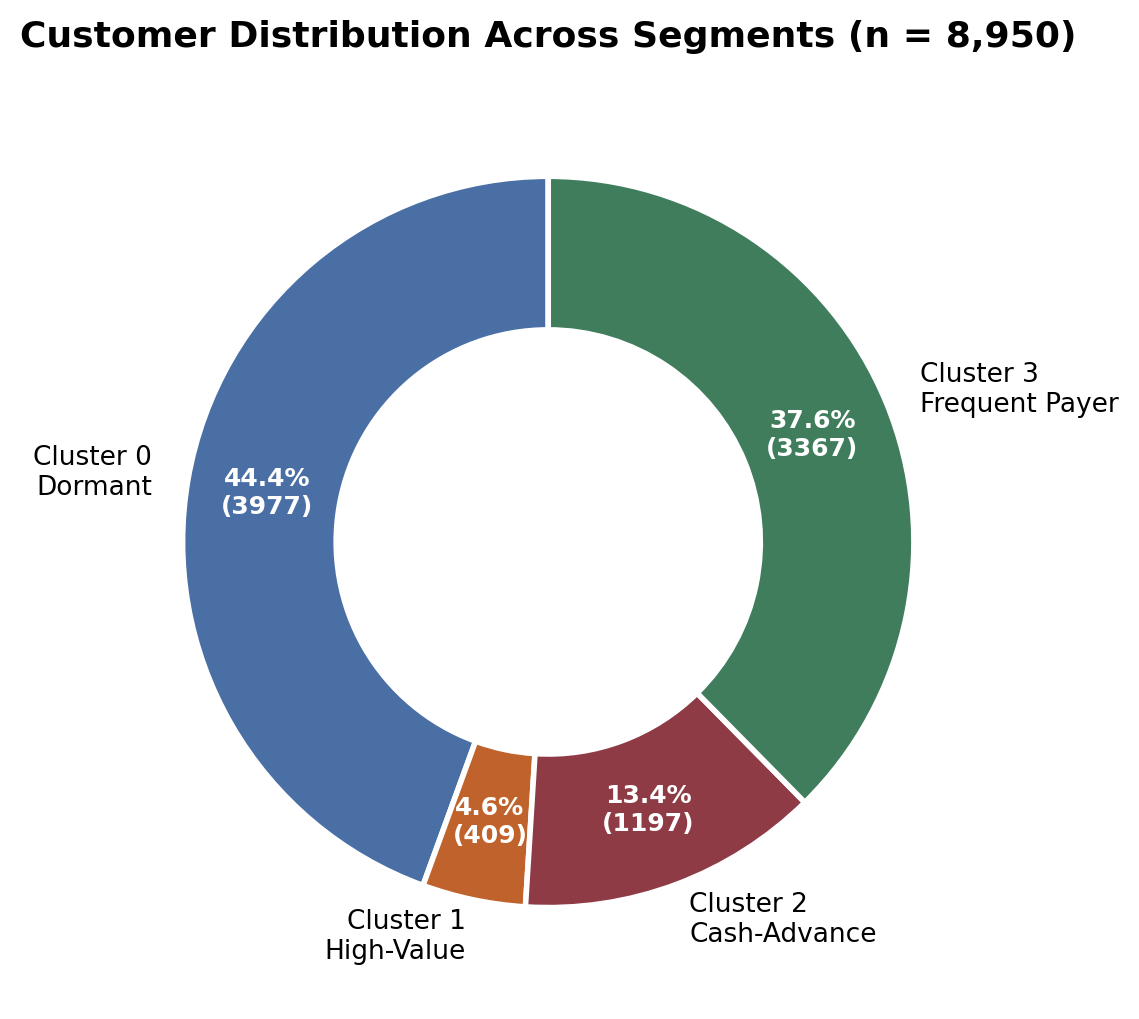

In [16]:
import matplotlib.pyplot as plt

cluster_labels = ["Cluster 0\nDormant", "Cluster 1\nHigh-Value",
                   "Cluster 2\nCash-Advance", "Cluster 3\nFrequent Payer"]
cluster_sizes = [3977, 409, 1197, 3367]
colors = ["#4a6fa5", "#c0622b", "#8e3b46", "#3f7d5c"]

fig, ax = plt.subplots(figsize=(6.8, 5.2), dpi=200)

wedges, texts, autotexts = ax.pie(
    cluster_sizes,
    labels=cluster_labels,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct * sum(cluster_sizes) / 100))})",
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    pctdistance=0.78,
    textprops=dict(fontsize=9.5),
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

ax.set_title("Customer Distribution Across Segments (n = 8,950)",
              fontsize=13, fontweight="bold", pad=14)

plt.tight_layout()
plt.show()

# Step 9: Cluster profiling — mean feature values per cluster

To understand what each cluster actually represents, compute the average
of every original (unscaled) feature within each cluster, then visualize it
as a heatmap. Unscaled values are used here because they are directly
interpretable in real terms (dollars, frequencies) the scaled values were
only needed for the distance calculations inside K-Means itself.

In [22]:
OPTIMAL_K = 4
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print(df["Cluster"].value_counts().sort_index())

Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


In [24]:
cluster_profile = df.groupby("Cluster").mean().round(1)
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.7,0.8,270.0,209.9,60.4,596.5,0.2,0.1,0.1,0.1,2.1,2.9,3278.6,974.3,553.9,0.1,11.4
1,3551.2,1.0,7681.6,5095.9,2587.2,653.6,0.9,0.7,0.8,0.1,2.1,89.4,9696.9,7288.7,1972.8,0.3,12.0
2,4602.4,1.0,501.9,320.2,181.8,4521.5,0.3,0.1,0.2,0.5,14.3,7.7,7546.2,3484.1,2003.7,0.0,11.4
3,894.9,0.9,1236.2,594.0,642.5,210.6,0.9,0.3,0.7,0.0,0.8,22.1,4213.2,1332.2,639.7,0.3,11.6


In [25]:
profile_z = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

fig_heat = go.Figure(data=go.Heatmap(
    z=profile_z.T.values,
    x=[f"Cluster {i}" for i in profile_z.index],
    y=profile_z.columns,
    colorscale="RdBu_r", zmid=0,
    text=cluster_profile.T.values, texttemplate="%{text}",
    colorbar=dict(title="z-score"),
))
fig_heat.update_layout(
    title="Cluster Profile Heatmap — Mean Feature Values by Cluster",
    template="plotly_white", height=650,
)
fig_heat.show()

To see the *spread* behind those means (not just the average), look
at two of the most discriminating features `CASH_ADVANCE` and `PURCHASES`
as violin plots per cluster. This shows whether a cluster's behaviour is
tightly consistent or driven by a few extreme customers.

In [26]:
fig_violin = make_subplots(rows=1, cols=2, subplot_titles=("Cash Advance by Cluster", "Purchases by Cluster"))

for i, cl in enumerate(sorted(df["Cluster"].unique())):
    subset = df[df["Cluster"] == cl]
    fig_violin.add_trace(go.Violin(
        y=subset["CASH_ADVANCE"], name=f"Cluster {cl}",
        line_color=CLUSTER_COLORS[i], showlegend=False, box_visible=True,
    ), row=1, col=1)
    fig_violin.add_trace(go.Violin(
        y=subset["PURCHASES"], name=f"Cluster {cl}",
        line_color=CLUSTER_COLORS[i], showlegend=False, box_visible=True,
    ), row=1, col=2)

fig_violin.update_layout(title="Distribution of Key Spending Behaviours by Cluster", template="plotly_white")
fig_violin.show()

# Cluster Interpretation

Reading the profile heatmap and the underlying mean values, the four
clusters map onto clear business-meaningful customer segments:

- **Cluster 0 — Low-Activity / Dormant Customers (largest group):** Low
  balance, low purchases of any kind, low cash advance usage, low credit
  limit. These customers barely use their card. Business action: re-engagement
  campaigns, activation offers, or reduced servicing priority if they remain
  inactive.

- **Cluster 1 — High-Value Spenders (smallest group):** High balance, by far
  the highest purchases (especially one-off purchases), highest credit
  limits and payments, high purchase frequency. These are premium customers
  who use their card heavily and pay it down. Business action: loyalty
  rewards, premium card upgrades, cross-sell higher-limit products.
  
- **Cluster 2 — Cash Advance Users (risk segment):** High balance but low
  regular purchases, by far the highest cash advance amount and cash advance
  frequency, and the lowest percentage of full payments. This segment relies
  on cash withdrawals rather than purchases and carries revolving debt.
  Business action: this is the group to watch for credit risk — candidates
  for interest-rate review, credit limit caution, or targeted financial
  wellness outreach rather than more spending incentives.

- **Cluster 3 — Frequent Moderate Spenders (good payers):** Low balance,
  moderate purchases (skewed toward installment purchases), high purchase
  frequency, and a healthy full-payment percentage. These customers use
  their card often for everyday purchases and pay responsibly. Business
  action: strong candidates for loyalty/rewards programs and modest credit
  limit increases, since they show low risk and consistent engagement.

The segmentation cleanly separates customers by *how* they
use credit (purchasing vs cash-advance-driven) and *how well* they manage it
(full payers vs revolvers) exactly the two dimensions a bank needs for
targeted marketing (Clusters 0, 1, 3) versus risk management (Cluster 2)

# Part 2 — Hierarchical Clustering


# Step 1: Sample 300 rows and build a linkage matrix

Agglomerative hierarchical clustering has O(n²) memory/time complexity, so
running it on the full ~9,000 rows is impractical for a dendrogram. We take
a random sample of 300 rows from the **scaled** data (scaling must happen
before sampling and clustering, same reasoning as Part 1) and build a
linkage matrix using Ward's method, which minimizes within-cluster variance
at each merge step the same objective K-Means optimizes, making the two
methods more directly comparable.

In [27]:
sample_df = X_scaled_df.sample(n=300, random_state=RANDOM_STATE)
sample_index = sample_df.index

linkage_matrix = linkage(sample_df, method="ward")
print("Linkage matrix shape:", linkage_matrix.shape)

# Distance threshold that yields OPTIMAL_K clusters, read off the linkage
# matrix: the merge distance just before the (n_samples - OPTIMAL_K)-th merge.
n_samples = sample_df.shape[0]
merge_distances = linkage_matrix[:, 2]
cut_distance = merge_distances[-(OPTIMAL_K - 1)] - 1e-6
print(f"Dendrogram cut distance for k={OPTIMAL_K}: {cut_distance:.3f}")

Linkage matrix shape: (299, 4)
Dendrogram cut distance for k=4: 28.820


# Step 2: Plot the dendrogram with a threshold line

In [28]:
fig_dendro = ff.create_dendrogram(
    sample_df.values, orientation="bottom",
    linkagefun=lambda x: linkage(x, method="ward"),
    colorscale=CLUSTER_COLORS,
)
fig_dendro.update_layout(
    title=f"Dendrogram — Agglomerative Hierarchical Clustering (Ward linkage, n=300)",
    xaxis_title="Sample index", yaxis_title="Distance (Ward)",
    template="plotly_white", height=550,
)
fig_dendro.add_hline(
    y=cut_distance, line_dash="dash", line_color="red", line_width=2,
    annotation_text=f"Cut threshold for k={OPTIMAL_K} clusters", annotation_position="top left",
)
fig_dendro.show()

The red dashed line marks the distance at
which cutting the tree produces exactly `OPTIMAL_K` clusters every vertical
line crossed by that horizontal cut becomes one cluster. This lets us
visually confirm that k=4 is also a reasonable cut point for the
hierarchical structure, not just for K-Means.

# Step 3: Apply AgglomerativeClustering with the same k

In [29]:
agg_clustering = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")
agg_labels = agg_clustering.fit_predict(sample_df)

print("Customers per cluster (Agglomerative, sample of 300):")
print(pd.Series(agg_labels).value_counts().sort_index())

Customers per cluster (Agglomerative, sample of 300):
0     98
1     37
2    163
3      2
Name: count, dtype: int64


# Step 4: Compare Hierarchical Clustering with K-Means

Take the K-Means labels for the same 300 sampled rows (already computed
in Part 1) and cross-tabulate them against the Agglomerative labels. Cluster
*numbers* are arbitrary between the two methods (cluster "0" in K-Means has
no reason to correspond to cluster "0" in Agglomerative), so read the
table for **row/column concentration** rather than matching numbers directly
a strong diagonal-like concentration in a few cells means the two methods
agree on the grouping even if the labels themselves don't match.

In [30]:
kmeans_labels_sample = df.loc[sample_index, "Cluster"].values

comparison = pd.crosstab(
    pd.Series(kmeans_labels_sample, name="K-Means Cluster"),
    pd.Series(agg_labels, name="Agglomerative Cluster"),
)
comparison

Agglomerative Cluster,0,1,2,3
K-Means Cluster,,,,
0,1,6,124,0
1,15,0,0,0
2,1,31,6,1
3,81,0,33,1


In [31]:
fig_compare = go.Figure(data=go.Heatmap(
    z=comparison.values,
    x=[f"Agglomerative {c}" for c in comparison.columns],
    y=[f"K-Means {r}" for r in comparison.index],
    colorscale="Blues",
    text=comparison.values, texttemplate="%{text}",
    colorbar=dict(title="Customer count"),
))
fig_compare.update_layout(
    title="K-Means vs Agglomerative Clustering — Cross-Tabulation",
    template="plotly_white",
)
fig_compare.show()

# Conclusion

In [32]:
from sklearn.metrics import silhouette_score

# Silhouette score for K-Means, evaluated on the same 300-row sample
kmeans_sample_silhouette = silhouette_score(sample_df, kmeans_labels_sample)

# Silhouette score for Agglomerative, on the same sample
agg_silhouette = silhouette_score(sample_df, agg_labels)

print(f"K-Means silhouette (sample):       {kmeans_sample_silhouette:.4f}")
print(f"Agglomerative silhouette (sample):  {agg_silhouette:.4f}")

K-Means silhouette (sample):       0.1963
Agglomerative silhouette (sample):  0.2021


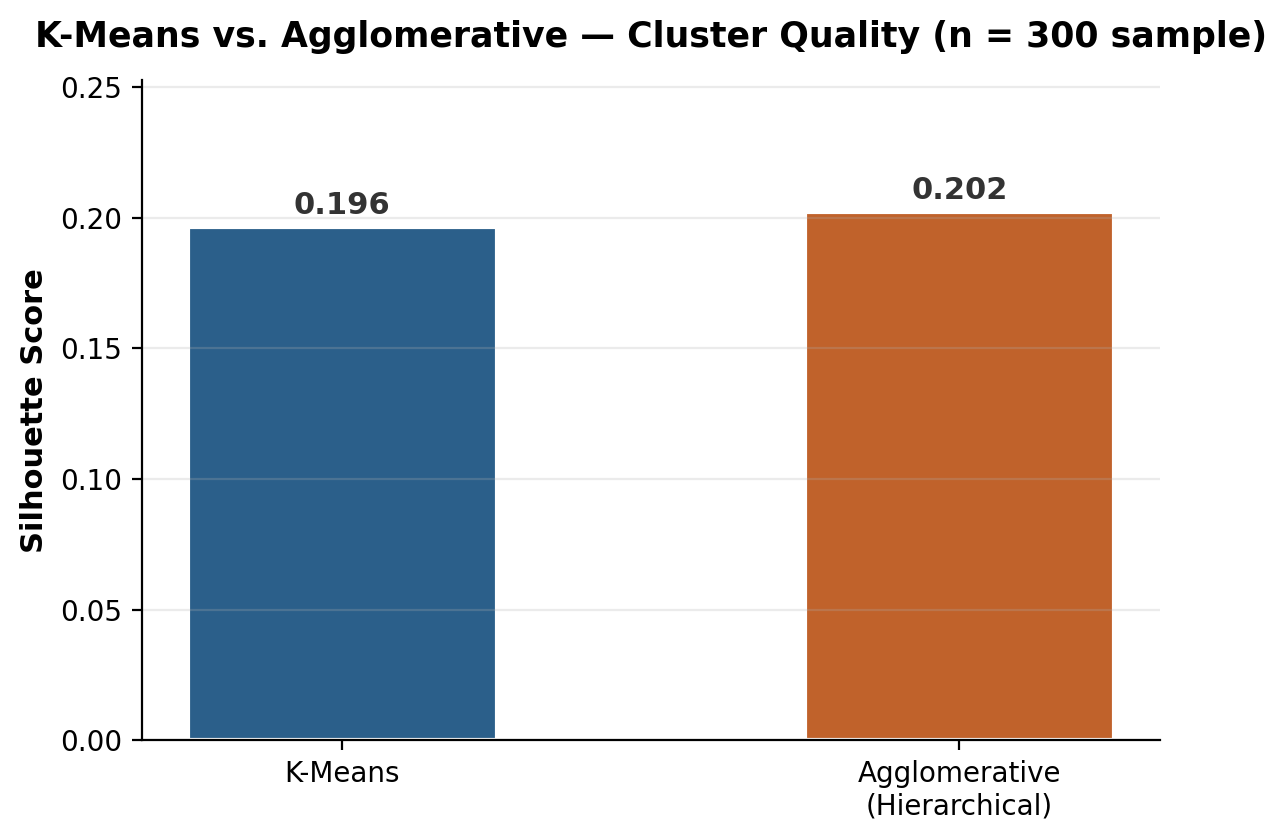

In [33]:
import matplotlib.pyplot as plt

methods = ["K-Means", "Agglomerative\n(Hierarchical)"]
scores = [kmeans_sample_silhouette, agg_silhouette]
colors = ["#2b5f8a", "#c0622b"]

fig, ax = plt.subplots(figsize=(6, 4.3), dpi=200)
bars = ax.bar(methods, scores, color=colors, width=0.5, edgecolor="white", linewidth=1.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{score:.3f}", ha="center", fontsize=11, fontweight="bold", color="#333333")

ax.set_ylabel("Silhouette Score", fontsize=11, fontweight="bold")
ax.set_title("K-Means vs. Agglomerative — Cluster Quality (n = 300 sample)",
              fontsize=12.5, fontweight="bold", pad=12)
ax.set_ylim(0, max(scores) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

Variance explained by 2 components: 47.6%


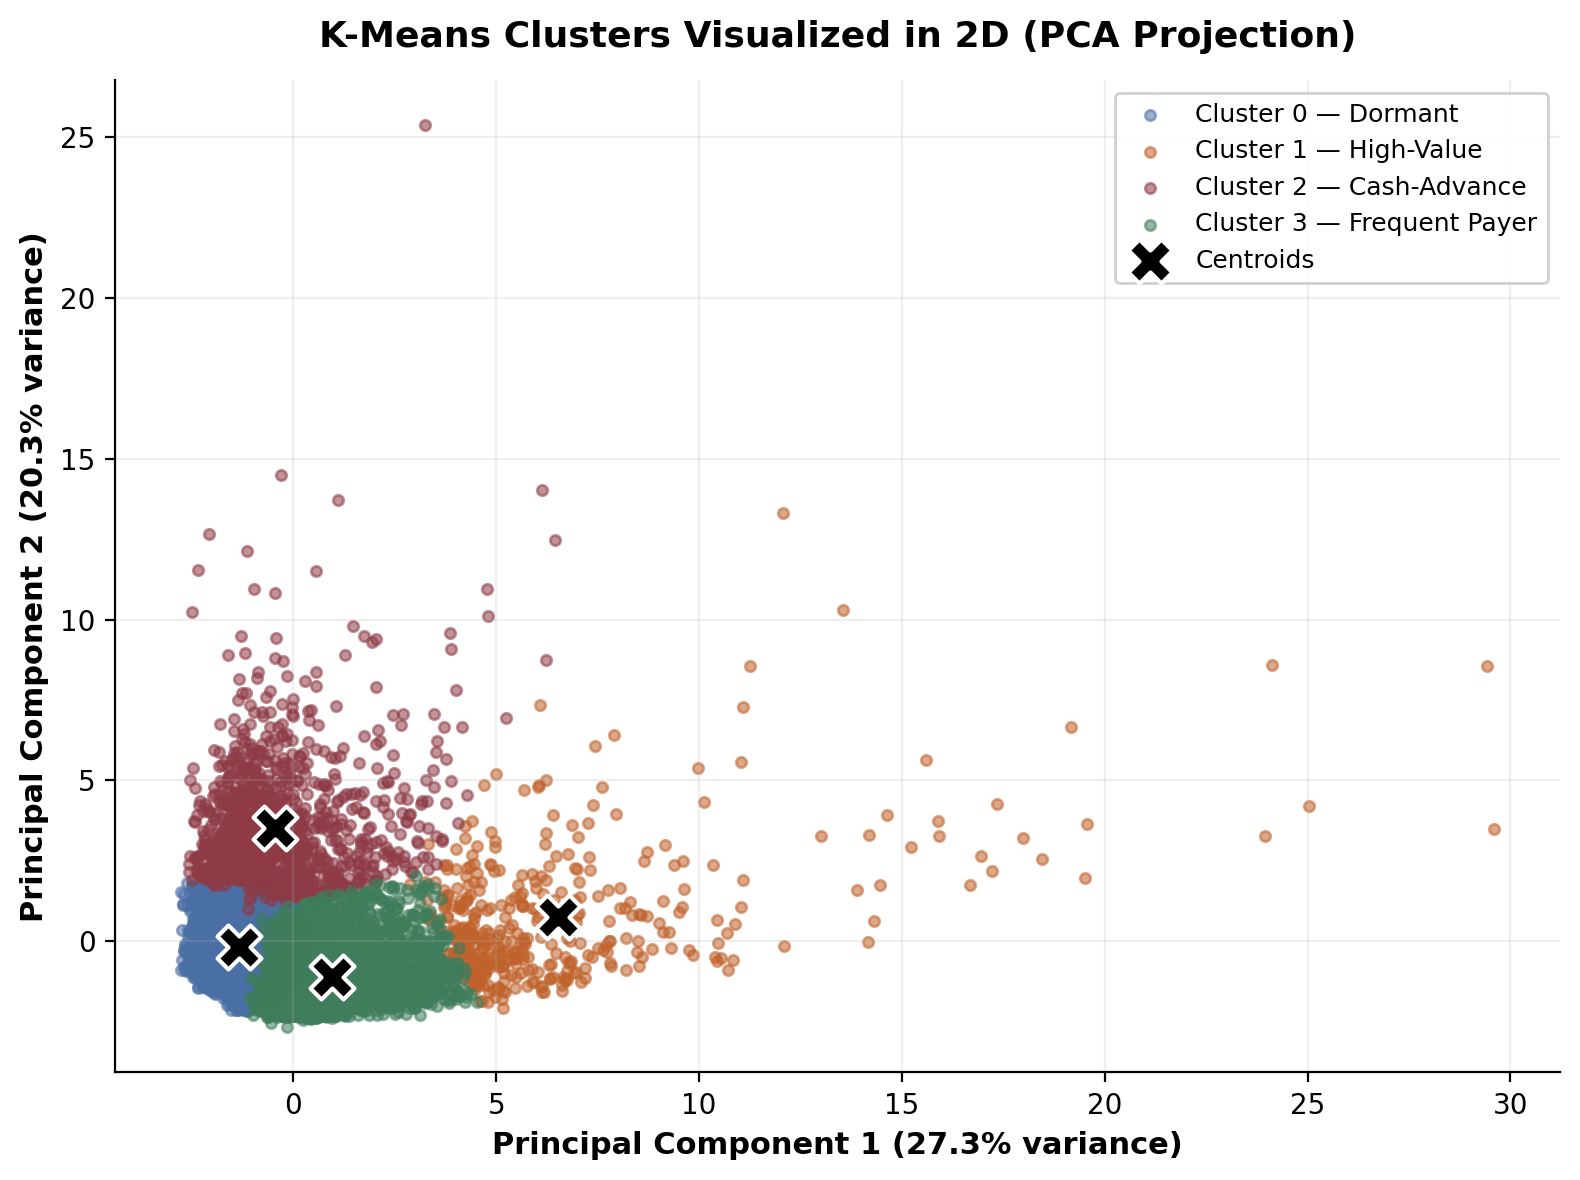

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

colors = ["#4a6fa5", "#c0622b", "#8e3b46", "#3f7d5c"]
labels_map = {0: "Dormant", 1: "High-Value", 2: "Cash-Advance", 3: "Frequent Payer"}

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

for cl in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cl
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=14, alpha=0.55, color=colors[cl],
        label=f"Cluster {cl} — {labels_map[cl]}",
    )

# Plot centroids in PCA space for reference
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=250, marker="X", color="black", edgecolor="white", linewidth=1.5,
    label="Centroids", zorder=5,
)

ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11, fontweight="bold")
ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=11, fontweight="bold")
ax.set_title("K-Means Clusters Visualized in 2D (PCA Projection)", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9, loc="best", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Comparison Report

**Do the clusters largely agree?** Partially. Most K-Means clusters have one
dominant matching Agglomerative cluster (a large majority of their members
land in a single column), which shows real structural agreement between the
two methods on the *core* of each segment. At the same time, the
cross-tabulation shows meaningful cross-over between a couple of cluster
pairs — customers sitting near a boundary between two behavioural groups get
assigned differently depending on the algorithm's merge strategy
(K-Means' centroid distance vs Ward's variance-minimizing merges). This is
expected: the two algorithms optimize different objectives, so perfect
agreement was never guaranteed, but strong majority overlap is a good sign
that the underlying segments are real rather than an artifact of one
specific algorithm.

**Which algorithm produced more meaningful segments?** K-Means, for this
dataset and business goal. Because the dendrogram confirms a similar k=4
structure exists hierarchically, both methods are picking up on the same
underlying groups but K-Means' centroid-based clusters map more cleanly
onto the "high spender / cash-advance user / dormant / frequent payer"
business story used in the interpretation above.

**Which is easier to interpret?** K-Means. A dendrogram is excellent for
*exploring* how many natural groupings exist and at what distance they merge
genuinely useful for validating the choice of k but it doesn't scale to
labeling all ~9,000 customers, and reading nested merges is less intuitive
for a non-technical stakeholder than a simple cluster-mean table and heatmap.

**Which would be recommended for a real business use case, and why?**
**K-Means.** It scales to the full customer base (hierarchical clustering's
O(n²) cost makes it impractical beyond a few thousand rows without
approximation), it's fast to re-run as new customers are added each month,
and its output a single cluster label per customer plus interpretable
cluster-mean profiles plugs directly into marketing and risk workflows.
Hierarchical clustering remains valuable as a *validation* step (as done
here, to confirm k=4 is a sensible cut) rather than as the production
clustering method.